# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("unit2_ppt7_superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

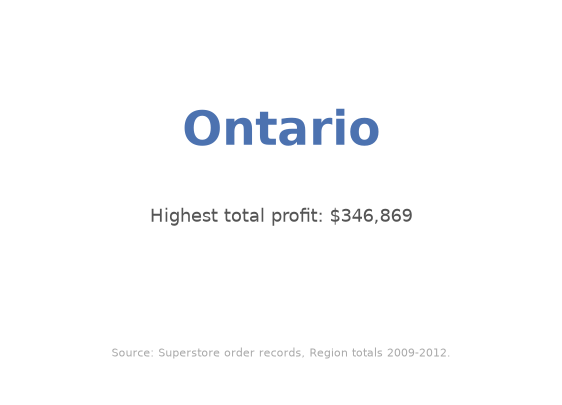

In [3]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(0.5, 0.65, best_region, ha="center", fontsize=34, fontweight="bold", color="#4C72B0")

# TODO 2: secondary element -- medium, muted color
ax.text(0.5, 0.45, f"Highest total profit: ${region_totals[best_region]:,.0f}",
        ha="center", fontsize=13, color="#555555")

# TODO 3: tertiary element -- small, light gray
ax.text(0.5, 0.1, "Source: Superstore order records, Region totals 2009-2012.",
        ha="center", fontsize=8, color="#aaaaaa")

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_ My eyes land on the region name first (largest, boldest, most saturated color), then the profit figure below it (medium size, muted gray), and only last -if at all - the small light-gray source footnote. In a 2-second glance, the one fact a viewer would walk away with is simply which region had the highest profit; the exact dollar figure and the data source are secondary details that only register on a closer look.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

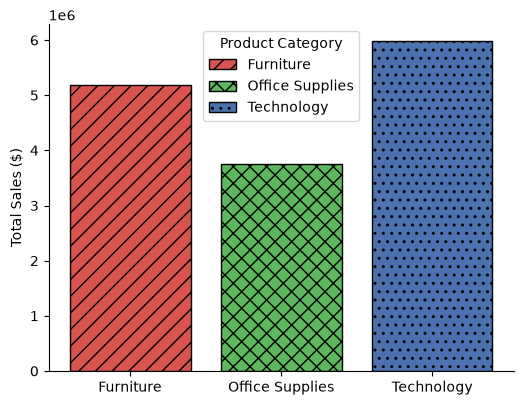

In [4]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat],
           edgecolor="black", label=cat) # TODO: plot one bar per category using colors[cat] and hatches[cat]

# TODO 3: legend
ax.legend(title="Product Category")
ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_ 1) Color blindness -- someone with red-green color vision deficiency could easily confuse the Furniture (red) and Technology/Office Supplies bars if they relied on color alone, since the hues would look similar or indistinguishable to them. 2) Grayscale printing -- if the chart is printed on a black-and-white/grayscale office printer, all three colored bars would collapse into similar shades of gray with no way to tell the categories apart; only the hatch patterns (added on top of color) would still distinguish them.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

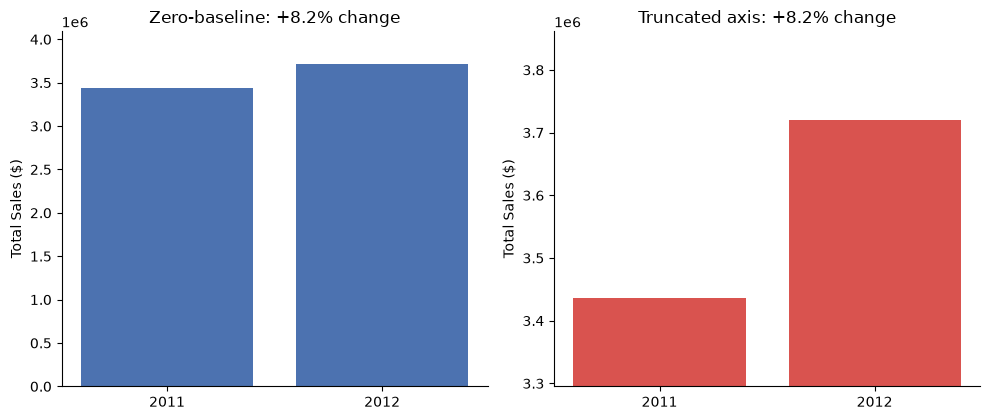

Real change from 2011 to 2012: +8.2%


In [5]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.1)
axes[0].set_title(f"Zero-baseline: {pct_change:+.1f}% change")
axes[0].set_ylabel("Total Sales ($)")

# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#D9534F")
margin = abs(v2 - v1) * 0.5
axes[1].set_ylim(min(v1, v2) - margin, max(v1, v2) + margin)
axes[1].set_title(f"Truncated axis: {pct_change:+.1f}% change")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%" if pct_change is not None else "Fill in pct_change above")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_ I'd flag the truncated-axis panel (the right one). Because its y-axis doesn't start at zero and is zoomed in tightly around the two values, the bar-height difference looks dramatic even though both panels show the exact same underlying percent change. A reader who only sees that chart, without the zero-baseline version next to it for context, would likely overestimate how large the year-over-year swing actually was. The zero-baseline panel shows the same real change but keeps the visual proportions honest, so it's the safer standalone headline chart.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales in the most recent period were higher than in the prior period.
INTERPRETIVE: Sales rose in the most recent period, which may reflect the new strategy, though other factors (seasonality, pricing, market conditions) could also be contributing.


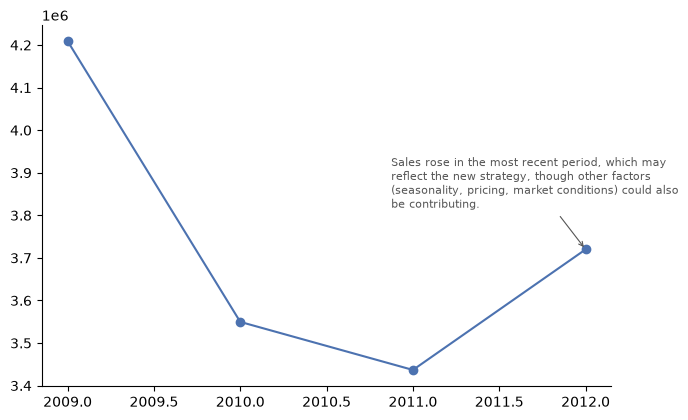

In [6]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1: your rewrites
descriptive_version = "Sales in the most recent period were higher than in the prior period."
interpretive_version = ("Sales rose in the most recent period, which may reflect the new "
                         "strategy, though other factors (seasonality, pricing, market "
                         "conditions) could also be contributing.")

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
# TODO: ax.annotate(...) using interpretive_version, pointing at the last year's value
last_year = yearly_sales.index[-1]
last_val = yearly_sales.values[-1]
ax.annotate(interpretive_version,
            xy=(last_year, last_val), xytext=(-140, 30), textcoords="offset points",
            fontsize=8, color="#555555", wrap=True,
            arrowprops=dict(arrowstyle="->", color="#555555", lw=0.8))

plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_ To justify a causal "proves it's working" claim I'd need, at minimum: a clear definition of when the new strategy actually launched and confirmation the sales uptick started after that date, not before; a comparison against a control group or a counterfactual baseline (e.g., a similar region/segment that didn't get the strategy, or a pre-registered forecast of what sales would have been without it); a check that other explanations -- seasonality, a broader market upswing, a pricing change, one-off large orders, marketing spend changes -- have been ruled out or controlled for; and ideally enough data points after the change to see whether the effect is sustained rather than a short-term blip. A single before/after comparison on aggregate sales data cannot establish causation on its own.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_ sign-off on the four charts: The most urgent fix to ship before tomorrow is the axis-truncation issue in the headline year-over-year chart (Task 3): a chart that visually exaggerates a small real change is the one most likely to mislead an executive skimming the report, and it's a quick fix (redraw with a zero baseline or clearly label the truncated axis). One of the audit questions -- "does the visual magnitude of the change match the real magnitude of the change?" -- applies directly here: the truncated panel fails this test, since a modest percent change is rendered as a dramatic-looking jump. The same audit question is relevant to Task 4's annotation, where "PROVES" implies a magnitude of certainty the data doesn't support. Going forward, I'd recommend adding a mandatory second-reviewer sign-off step before any chart with quantitative axes ships, specifically checking that (a) axes start at zero or are explicitly labeled as truncated, and (b) no annotation uses causal language ("proves," "because of") without supporting evidence beyond the single dataset shown.

